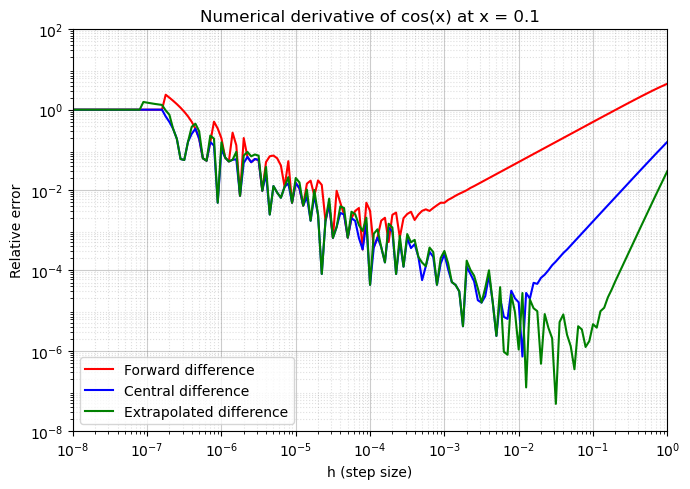

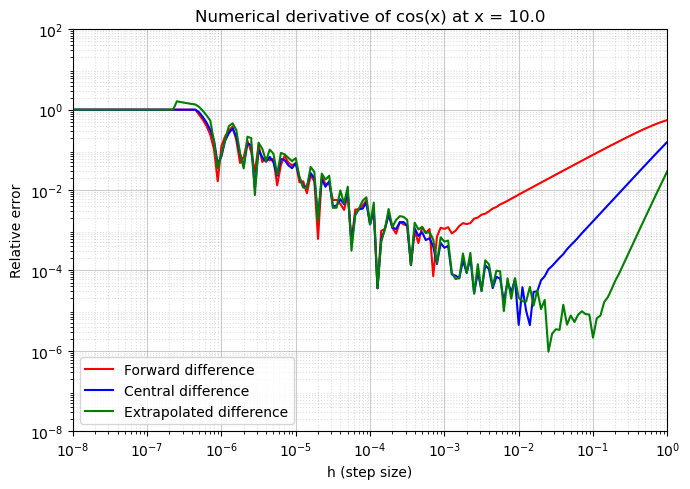

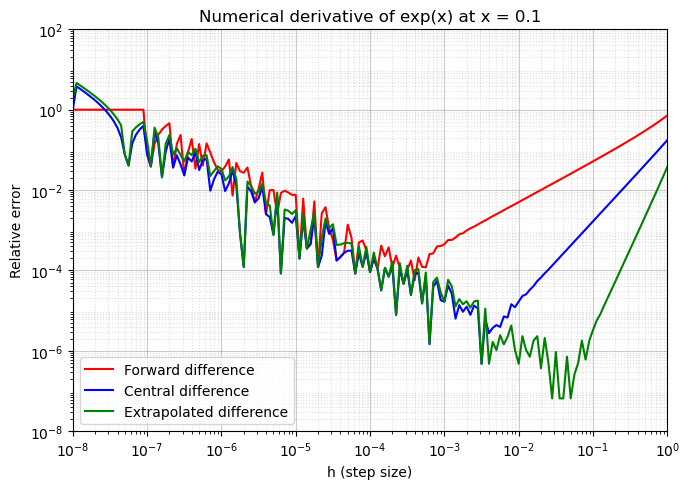

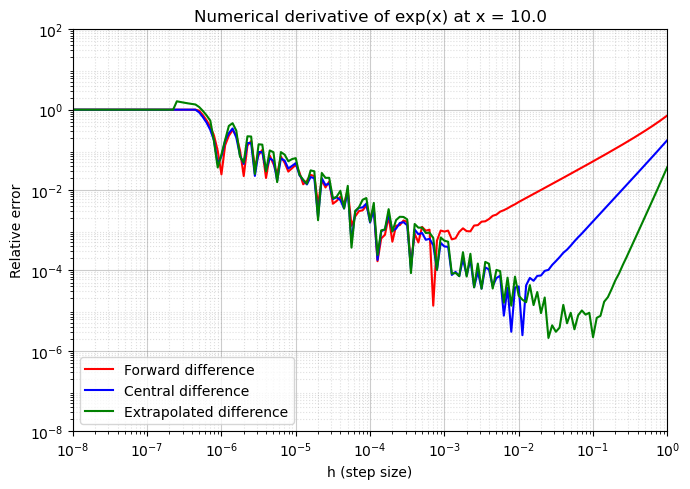

In [22]:
# Single precision numerical differentiation of cos(x) and exp(x)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


#define functions:

def fn_cos(x):
    return np.float32(np.cos(np.float32(x)))

def fn_exp(x):
    return np.float32(np.exp(np.float32(x)))


#true derivatives:

def true_deriv_cos(x):
    return -np.sin(x)

def true_deriv_exp(x):
    return np.exp(x)


#numerical differentiation methods:

def diff_forward(func, x, h):
    x = np.float32(x)
    h = np.float32(h)
    numerator = func(x + h) - func(x)
    return numerator / h


def diff_central(func, x, h):
    x = np.float32(x)
    h = np.float32(h)
    numerator = func(x + h) - func(x - h)
    denom = np.float32(2.0) * h
    return numerator / denom


def diff_extrapolated(func, x, h):
    h = np.float32(h)
    est_full = diff_central(func, x, h)
    est_double = diff_central(func, x, np.float32(np.float32(2.0)*h))
    combined = ((np.float32(4.0) * est_full) - est_double) / np.float32(3.0)
    return combined


#measuring relative error of estimate:

def relative_error(estimate, true_value):
    return abs((float(estimate) - true_value) / true_value)


#sweeping over h and plotting errors:

def study_case(func, true_deriv_func, label, x, save_file):
    step_sizes = np.logspace(0, -8, 161, dtype=np.float32)
    true_value = true_deriv_func(x)

    err_forward = []
    err_central = []
    err_extrap = []

    for step in step_sizes:
        val_forward = diff_forward(func, x, step)
        val_central = diff_central(func, x, step)
        val_extrap = diff_extrapolated(func, x, step)

        err_forward.append(relative_error(val_forward, true_value))
        err_central.append(relative_error(val_central, true_value))
        err_extrap.append(relative_error(val_extrap, true_value))

    err_forward = np.array(err_forward)
    err_central = np.array(err_central)
    err_extrap = np.array(err_extrap)

    #making log-log plot of error vs step size
    fig, ax = plt.subplots(figsize=(7, 5))

    #Adding colors: Red, Blue, Green
    ax.loglog(step_sizes, err_forward, label="Forward difference", color="red")
    ax.loglog(step_sizes, err_central, label="Central difference", color="blue")
    ax.loglog(step_sizes, err_extrap, label="Extrapolated difference", color="green")

    #Axes
    ax.set_xlim(1e-8, 1.0)
    ax.set_ylim(1e-8, 100.0)

    #Tick marks
    ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
    ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
    ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))

    ax.set_xlabel("h (step size)")
    ax.set_ylabel("Relative error")
    ax.set_title(f"Numerical derivative of {label} at x = {x}")
    
    #Position legend
    ax.legend(loc="lower left")

    #Major and minor grids
    ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.4)
    ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.25)

    plt.tight_layout()
    plt.savefig(save_file, dpi=200)
    plt.show()


#run for specified x values 

study_case(fn_cos, true_deriv_cos, "cos(x)", 0.1, "cos_x01.png")
study_case(fn_cos, true_deriv_cos, "cos(x)", 10.0, "cos_x10.png")
study_case(fn_exp, true_deriv_exp, "exp(x)", 0.1, "exp_x01.png")
study_case(fn_exp, true_deriv_exp, "exp(x)", 10.0, "exp_x10.png")